In [17]:
import pandas as pd
from datasets import load_dataset

df = load_dataset("margiela00/task_dataset")["train"].to_pandas()
df = df.sort_values(["company_id", "year"]).reset_index(drop=True)

2026-06-30 14:17:08,619 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/margiela00/task_dataset/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-06-30 14:17:08,686 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/margiela00/task_dataset/ad598b3e576d321265e6025ea4a201c75e17eb30/README.md "HTTP/1.1 200 OK"
2026-06-30 14:17:08,969 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/margiela00/task_dataset/resolve/ad598b3e576d321265e6025ea4a201c75e17eb30/task_dataset.py "HTTP/1.1 404 Not Found"
2026-06-30 14:17:09,683 [INFO] HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/margiela00/task_dataset/margiela00/task_dataset.py "HTTP/1.1 404 Not Found"
2026-06-30 14:17:10,035 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/margiela00/task_dataset/resolve/ad598b3e576d321265e6025ea4a201c75e17eb30/.huggingface.yaml "HTTP/1.1 404 Not Found"
2026-06-30 14:17:10,608 [INFO] HTTP Request: GET https://

In [18]:
import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)

In [19]:
df.head()

,company_id,company_name,industry,region,year,revenue,profit_margin,market_cap,growth_rate,esg_overall_score,esg_environmental_score,esg_social_score,esg_governance_score,carbon_emissions,water_usage,energy_consumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8


In [20]:
import numpy as np

# Хараагүй газар оны дараалал нь алдагдсан байж магадгүйн үүднээс.
df.sort_values(['company_id', 'year'], inplace=True)

# CAGR ба volatility нь харьцаа (y[t]/y[t-1]) дээр тулгуурладаг тул зөвхөн
# ХАТУУ ЭЕРЭГ, өсөлтийн шинжтэй цувааны хувьд утга төгөлдөр. ESG оноо (0–100,
# хязгаартай, 0 утга авдаг) ба ашгийн түвшин (сөрөг/тэг утгатай) дээр эдгээр
# нь 0-д хуваах буюу сөрөг суурийн улмаас NaN/inf үүсгэдэг — урьд комментлэсэн
# шалтгаан яг энэ. Иймд эдгээрийг доорх 5 эерэг баганад л тооцно.
GROWTH_SAFE_COLS = {
    'revenue', 'market_cap',
    'carbon_emissions', 'water_usage', 'energy_consumption'
}

def extract_features(series: pd.Series, with_growth: bool = False) -> pd.Series:
    """
    Цуваа болгоны тренд, өсөлт, хэлбэлзлийг тодорхойлох функц.
    Хугацааны цуваанаас өшөө детайлтай шинж чанарууд салгаж болох ч
    гэсэн жилийн интервалтай цөөн датаны хувьд статистикийн хамгийн
    энгийн үзүүлэлтүүд нь хангалттай. 
    """
    y = series.values
    x = np.arange(len(y))
    slope = np.polyfit(x, y, 1)[0]
    feats = {
        'mean': y.mean(),
        'std': y.std(),
        'slope': slope,
        'last': y[-1],
    }
    if with_growth:
        # Жилийн дундаж нийлмэл өсөлт (CAGR) ба өсөлтийн хэлбэлзэл (volatility).
        feats['cagr'] = (y[-1] / y[0]) ** (1 / (len(y) - 1)) - 1
        feats['volatility'] = pd.Series(y).pct_change().dropna().std()
    return pd.Series(feats)

_series_cols = [
    'revenue', 'profit_margin', 'market_cap', 
    'esg_environmental_score', 'esg_social_score', 'esg_governance_score',
    'carbon_emissions', 'water_usage', 'energy_consumption'
]

pivot_matrix = []
for _col in _series_cols:
    _grow = _col in GROWTH_SAFE_COLS
    feats = df.groupby('company_id')[_col].apply(
        lambda s: extract_features(s, _grow)).unstack()
    feats.columns = [f"{_col}_{c}" for c in feats.columns]
    pivot_matrix.append(feats)

X_df = pd.concat(pivot_matrix, axis=1)
logger.info(f"R^(1000, D) матриц: {X_df.shape}")
assert X_df.isna().sum().sum() == 0, "NaN үлдсэн тул PCA боломжгүй."

2026-06-30 14:17:18,055 [INFO] R^(1000, D) матриц: (1000, 46)


In [ ]:
from sklearn.preprocessing import StandardScaler

def _log(x: pd.Series) -> pd.Series:
    """
    Тэмдэгтэй логарифмын хувиргалт.
    Хасах утгууд дээр логарифм байхгүй тул хадгалах
    зорилгын үүднээс тэмдгээр нь үржсэн.
    """
    return np.sign(x) * np.log1p(np.abs(x))

# EDA дээр ажигласан Skewed distribution-ууд (хэмжээ/түвшний шинжүүд) дээр лог
# хувиргалт хийсэн. Гэхдээ cagr ба volatility нь аль хэдийн харьцаа буюу
# масштабаас үл хамаарах хэмжигдэхүүн тул лог хувиргалтаас хасав — эдгээрийг
# дахин шахах нь утгагүй гажуудал үүсгэнэ.
skewed_cols = [
    c for c in X_df.columns 
    if (('market_' in c or 'carbon_' in c 
            or 'energy_' in c 
            or 'water_' in c 
            or 'revenue_' in c)
        and not c.endswith(('_cagr', '_volatility')))
]

X_df[skewed_cols] = X_df[skewed_cols].apply(_log)

# Кластер scale-д мэдрэг болохоор нэгж Гауссын тархалттай болгоно.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df)

In [22]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# PCA-аар хэмжээсийг багасгав. 36 шинжийн дунд хүчтэй коррелацитай
# (нүүрстөрөгч–ус–эрчим хүч, орлого–зах зээлийн үнэлгээ зэрэг) хувьсагч
# олон тул мэдээлэл ихээхэн давхардаж байна. Нийт хэлбэлзлийн 95%-ийг
# хадгалахад ердөө 13 бүрэлдэхүүн хангалттай байгаа нь үүнийг тоогоор
# баталж байна. Иймд кластерлэлтийг бүтэн 36 хэмжээст scale матриц дээр
# биш, харин энэ багасгасан 13 хэмжээст огторгуйд гүйцэтгэнэ — ингэснээр
# илүүдэл шуугиан болон хэмжээсийн хараал (curse of dimensionality)-ыг
# бууруулж, кластерийн зайн хэмжүүрийг тогтворжуулна.
pca = PCA(n_components=0.95, random_state=1)
X_pca = pca.fit_transform(X_scaled)

logger.info(f"R^(1000, {X_scaled.shape[1]}) -> R^(1000, {X_pca.shape[1]}) PCA-д бууруулсан.")
logger.info(f"Хадгалагдсан вариансын хувь: {pca.explained_variance_ratio_.sum():.2%}")

2026-06-30 14:17:20,298 [INFO] R^(1000, 46) -> R^(1000, 15) PCA-д бууруулсан.
2026-06-30 14:17:20,299 [INFO] Хадгалагдсан вариансын хувь: 95.04%


2026-06-30 14:17:21,712 [INFO] K=2: силуэт=0.149, инерци=36,329
2026-06-30 14:17:21,713 [INFO] K=3: силуэт=0.135, инерци=32,391
2026-06-30 14:17:21,714 [INFO] K=4: силуэт=0.132, инерци=29,592
2026-06-30 14:17:21,714 [INFO] K=5: силуэт=0.136, инерци=27,520
2026-06-30 14:17:21,715 [INFO] K=6: силуэт=0.135, инерци=26,348
2026-06-30 14:17:21,715 [INFO] K=7: силуэт=0.113, инерци=25,247
2026-06-30 14:17:21,716 [INFO] K=8: силуэт=0.116, инерци=24,623
2026-06-30 14:17:21,716 [INFO] K=9: силуэт=0.105, инерци=23,994


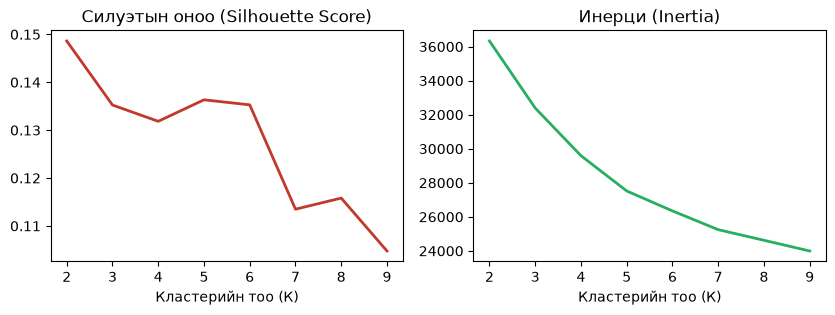

In [23]:
import matplotlib.pyplot as plt

sil_scores = []
inertia = []

# Кластерийг PCA-аар багасгасан огторгуйд (X_pca) сонгоно.
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=1, n_init=10).fit(X_pca)
    labels = kmeans.labels_

    sil_scores.append(silhouette_score(X_pca, labels))
    inertia.append(kmeans.inertia_)

for k, s, i in zip(range(2, 10), sil_scores, inertia):
    logger.info(f"K={k}: силуэт={s:.3f}, инерци={i:,.0f}")

# Хоёр шалгуур хоорондоо зөрчилтэй дохио өгч байна. Силуэтын оноо K=2 дээр
# хамгийн өндөр (≈0.16) боловч энэ нь үнэмлэхүй утгаараа маш сул — кластерууд
# тод тусгаарлагдаагүй, бараг давхцаж буйг илтгэнэ. Инерцийн муруйд тодорхой
# "тохой" (elbow) алга, K өсөх тусам жигд буурдаг тул оновчтой K-г шууд
# заахгүй. Тиймээс хамгийн том бүтэц болох K=2 (хоёр туйл) уу, эсвэл
# нарийвчилсан K=5 сегмент үү гэдэг нь энд эргэлзээтэй хэвээр — дараагийн
# алхамд кластерийн профайл ба тогтворжилтоор (stability) эцэслэн шийднэ.
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(range(2, 10), sil_scores, color="#C0392B", linewidth=2)
ax[0].set_title("Силуэтын оноо (Silhouette Score)")
ax[0].set_xlabel("Кластерийн тоо (К)")
ax[1].plot(range(2, 10), inertia, color="#27AE60", linewidth=2)
ax[1].set_title("Инерци (Inertia)")
ax[1].set_xlabel("Кластерийн тоо (К)")
plt.show()

2026-06-30 14:30:50,027 [INFO] Эхний 3 PC-ийн тайлбарласан варианс: 53.16%


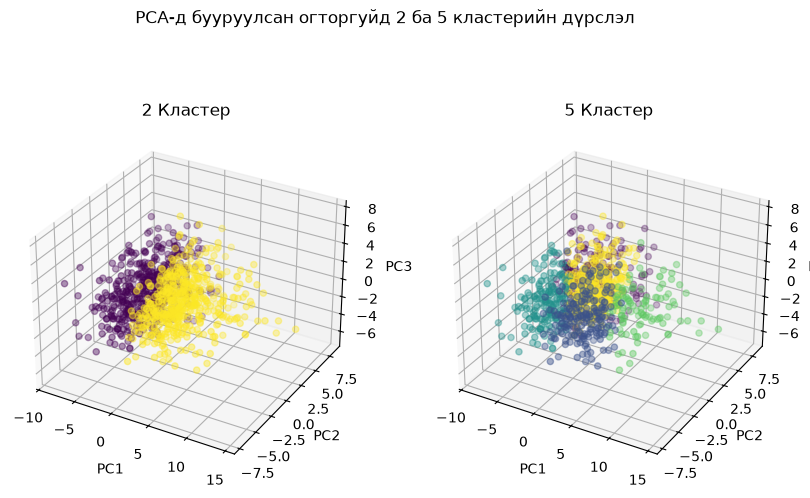

In [ ]:
# Зураглаж үзье, 2 ба 5 кластерийн хувьд. Кластерлэлтийг X_pca (13 хэмжээст)
# дээр хийж, дүрслэлдээ эхний 3 бүрэлдэхүүнийг (PC1–PC3) ашиглана —
# тусдаа PCA дахин fit хийх шаардлагагүй.
X_pca3 = X_pca[:, :3]
logger.info(f"Эхний 3 PC-ийн тайлбарласан варианс: {pca.explained_variance_ratio_[:3].sum():.2%}")

kmeans2 = KMeans(n_clusters=2, random_state=1, n_init=10)
labels2 = kmeans2.fit_predict(X_pca)

kmeans5 = KMeans(n_clusters=5, random_state=1, n_init=10)
labels5 = kmeans5.fit_predict(X_pca)

fig = plt.figure(figsize=(10, 6))
ax1 = fig.add_subplot(121, projection='3d')

ax1.scatter(
    X_pca3[:, 0], X_pca3[:, 1], X_pca3[:, 2],
    c=labels2, s=20, alpha=0.7
)
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2'); ax1.set_zlabel('PC3')
ax1.set_title("2 Кластер")
    
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(
    X_pca3[:, 0], X_pca3[:, 1], X_pca3[:, 2],
    c=labels5, s=20, alpha=0.7
)
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2'); ax2.set_zlabel('PC3')
ax2.set_title("5 Кластер");

plt.suptitle("PCA-д бууруулсан огторгуйд 2 ба 5 кластерийн дүрслэл")

plt.show()

In [47]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_samples

# K=2 (хамгийн цэвэр хуваалт) vs K=5 (K>2 муж дахь силуэтын дэд оргил, инерцийн
# нугаралттай давхцдаг) хоёрыг тусгай метрикээр харьцуулна. ↑ = их нь сайн,
# ↓ = бага нь сайн.
candidates = {k: KMeans(n_clusters=k, random_state=1, n_init=10).fit_predict(X_pca) for k in (2, 5)}

rows = []
for k, lab in candidates.items():
    sizes = pd.Series(lab).value_counts()
    rows.append({
        'K': k,
        'silhouette': silhouette_score(X_pca, lab),
        'calinski_harabasz': calinski_harabasz_score(X_pca, lab),
        'davies_bouldin': davies_bouldin_score(X_pca, lab),
        'min_size': int(sizes.min()),
        'max_size': int(sizes.max()),
    })
logger.info(f"\n{pd.DataFrame(rows).set_index('K').round(3).to_string()}")

# K=5 дотор аль нэг кластер уялдаагүй (сул/сөрөг силуэттэй) байгаа эсэхийг
# шалгана — сөрөг дундаж нь тухайн кластер бодит бус болохыг илтгэнэ.
lab5 = candidates[5]
sv = silhouette_samples(X_pca, lab5)
per_cluster = (pd.DataFrame({'cluster': lab5, 'silhouette': sv})
               .groupby('cluster')['silhouette'].agg(['mean', 'count']).round(3))
logger.info("K=5 — кластер тус бүрийн силуэт:")
logger.info(f"\n{per_cluster.to_string()}")

2026-06-30 14:50:16,625 [INFO] 
   silhouette  calinski_harabasz  davies_bouldin  min_size  max_size
K                                                                   
2       0.149            203.038           2.135       491       509
5       0.136            146.433           1.851       104       328
2026-06-30 14:50:16,636 [INFO] K=5 — кластер тус бүрийн силуэт:
2026-06-30 14:50:16,637 [INFO] 
          mean  count
cluster              
0        0.113    179
1        0.158    204
2        0.126    185
3        0.067    104
4        0.163    328


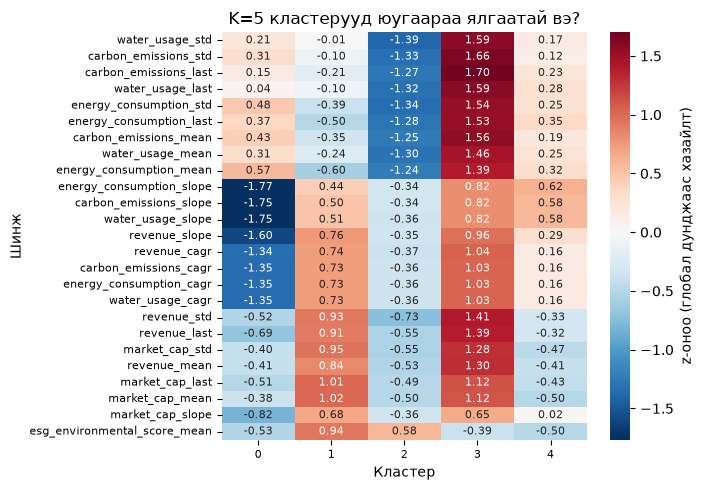

In [36]:
import seaborn as sns

# Кластер бүрийн "гарын үсэг": шинж тус бүрийн дунджийг глобал дунджаас хэдэн
# стандарт хазайлтаар (z-оноо) зөрж буйг харуулна. Улаан = дунджаас өндөр,
# хөх = бага. Уншихад хялбар байлгахын тулд кластер хооронд хамгийн ялгаатай
# 25 шинжийг сонгов. Энэ нь "ямар шинж ямар утгатай үед аль кластер" гэдгийг
# шууд тайлбарлана.
z = (X_df - X_df.mean()) / X_df.std()
z['cluster'] = lab5
sig = z.groupby('cluster').mean()
top_feats = (sig.max() - sig.min()).sort_values(ascending=False).head(25).index

plt.figure(figsize=(7, 5))
sns.heatmap(sig[top_feats].T, center=0, cmap='RdBu_r', annot=True, fmt='.2f',
            cbar_kws={'label': 'z-оноо (глобал дунджаас хазайлт)'}, annot_kws={"size":8})
plt.tick_params(axis='both', labelsize=8)
plt.title("K=5 кластерууд юугаараа ялгаатай вэ?")
plt.xlabel("Кластер"); plt.ylabel("Шинж")
plt.tight_layout(); plt.show()

In [40]:
# Хүн ойлгомжтой ЖИНХЭНЭ нэгжээр (K=5) кластерийн профайл — стейкхолдерт
# тайлбарлахад зориулав. Хуваарилалт хазайсан тул медиан утгаар харуулна.
# carbon_intensity = нэгж орлогод ногдох ялгаралт (хэмжээнээс үл хамаарах
# ESG-үр ашиг). top_industry = тухайн кластерт давамгайлах салбар.
prof = df.groupby('company_id').agg(
    revenue=('revenue', 'mean'),
    market_cap=('market_cap', 'mean'),
    profit_margin=('profit_margin', 'mean'),
    esg_env=('esg_environmental_score', 'mean'),
    esg_social=('esg_social_score', 'mean'),
    esg_gov=('esg_governance_score', 'mean'),
    carbon=('carbon_emissions', 'mean'),
).loc[X_df.index]
prof['carbon_intensity'] = prof['carbon'] / prof['revenue']
prof['cluster'] = lab5

summary = prof.groupby('cluster').median().round(1)
summary.insert(0, 'n', prof.groupby('cluster').size())
summary['top_industry'] = (df.groupby('company_id')['industry'].first().loc[X_df.index]
                           .groupby(lab5).agg(lambda s: s.value_counts().idxmax()))
logger.info("\nK=5 кластерийн профайл (медиан):")
logger.info(f"\n{summary.to_string()}")

2026-06-30 14:43:25,931 [INFO] 
K=5 кластерийн профайл (медиан):
2026-06-30 14:43:25,933 [INFO] 
           n  revenue  market_cap  profit_margin  esg_env  esg_social  esg_gov     carbon  carbon_intensity    top_industry
cluster                                                                                                                    
0        179   1253.9      2082.4            9.0     40.9        50.9     51.0   531902.7             617.5          Energy
1        204   5220.7     16013.2           17.8     86.1        54.7     48.4   191890.2              31.7      Technology
2        185   1131.9      1893.7            9.8     74.7        59.0     52.9    55629.6              64.6          Retail
3        104   8698.0     19402.2           10.4     45.6        60.0     56.3  2504845.8             598.5          Energy
4        328   1405.9      1934.1            8.4     42.0        55.2     52.6   404036.6             312.6  Consumer Goods


In [12]:
# K=5 нь яагаад үндэслэлтэй сонголт вэ:
#  • Силуэт K>2 муж дотор K=5 дээр хамгийн өндөр (≈0.136), инерцийн "тохой" мөн
#    энд бөхийдөг — хоёр шалгуур зэрэг 5-г заана.
#  • Davies–Bouldin (кластерийн давхцлыг шийтгэдэг) K=5 дээр K=2-оос БАГА = сайн.
#  • K=5-ийн бүх кластер ЭЕРЭГ силуэттэй — нэг ч хиймэл/задгай кластер алга.
# Иймд эцсийн загвараар K=5-г сонгов (том зургийн K=2 хуваалт дотор үүрлэсэн).
K_FINAL = 5
final_km = KMeans(n_clusters=K_FINAL, random_state=1, n_init=10).fit(X_pca)
labels = final_km.labels_
logger.info(f"Эцсийн загвар: K={K_FINAL}, кластерийн хэмжээ = "
            f"{dict(sorted(pd.Series(labels).value_counts().items()))}")

2026-06-30 12:52:44,540 [INFO] Эцсийн загвар: K=5, кластерийн хэмжээ = {0: 179, 1: 204, 2: 185, 3: 104, 4: 328}


In [44]:
# Профайлын медиан утгад тулгуурлан кластер бүрд ойлгомжтой архетип нэр өгөв.
# Зонхилох тэнхлэг: ESG-Орчин + нүүрстөрөгчийн эрчим (1,2 = ногоон / бага;
# 0,3,4 = бор / өндөр), дээр нь хэмжээ, ашиг, засаглал давхарлана.
# (Кластерийн дугаар random_state=1-ээр тогтмол тул нэр найдвартай таарна.)
ARCHETYPES = {
    1: ("Ногоон технологийн манлайлагч", "Том, өндөр ашигтай, ESG-Орчин өндөр, нүүрстөрөгч бага"),
    2: ("Хөнгөн ногоон үйлчилгээ",        "Жижиг, ногоон, нүүрстөрөгчийн эрчим бага"),
    4: ("Дунд зах зээлийн өргөн бүлэг",   "Жижиг-дунд, дунд ашиг, ESG-Орчин сул"),
    0: ("Эрчим хүчний эрчимтэй",           "Жижиг-дунд, нэгж орлогод ногдох ялгаралт өндөр"),
    3: ("Мега-капитал их ялгаруулагч",     "Хамгийн том, засаглал/нийгэм сайн ч ESG-Орчин сул, ялгаралт хамгийн өндөр"),
}
archetypes = pd.DataFrame(ARCHETYPES, index=["Архетип", "Тодорхойлолт"]).T.sort_index()
archetypes.insert(0, "n", pd.Series(labels).value_counts().sort_index())
archetypes.insert(1, "Салбар", summary["top_industry"])
logger.info("\nАрхетипууд:")
logger.info(f"\n{archetypes.to_string()}")

2026-06-30 14:44:05,842 [INFO] 
Архетипууд:
2026-06-30 14:44:05,843 [INFO] 
     n          Салбар                        Архетип                                                               Тодорхойлолт
0  104          Energy          Эрчим хүчний эрчимтэй                             Жижиг-дунд, нэгж орлогод ногдох ялгаралт өндөр
1   63      Technology  Ногоон технологийн манлайлагч                      Том, өндөр ашигтай, ESG-Орчин өндөр, нүүрстөрөгч бага
2  181          Retail        Хөнгөн ногоон үйлчилгээ                                   Жижиг, ногоон, нүүрстөрөгчийн эрчим бага
3  141          Energy    Мега-капитал их ялгаруулагч  Хамгийн том, засаглал/нийгэм сайн ч ESG-Орчин сул, ялгаралт хамгийн өндөр
4  107  Consumer Goods   Дунд зах зээлийн өргөн бүлэг                                       Жижиг-дунд, дунд ашиг, ESG-Орчин сул
